# Выявление зон деградации растительного покрова по спутниковым изображениям

**Автор:** Раимова Алина

## Введение

Деградация растительного покрова в Сибири связана с лесными пожарами, антропогенной нагрузкой и изменением климата. Для мониторинга используются методы дистанционного зондирования.

**Цель:** выявить и картировать зоны деградации растительности на основе анализа временного ряда спутниковых изображений Landsat за период 2020-2024 гг.

**Задачи:**
1. Получить спутниковые снимки Landsat
2. Выполнить предобработку данных
3. Рассчитать вегетационный индекс NDVI
4. Проанализировать изменения во времени
5. Выделить зоны деградации
6. Оценить точность результатов

## Установка библиотек

In [1]:
# !pip install rasterio scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from datetime import datetime
import warnings
import os
import glob
import rasterio
from rasterio.plot import show
from scipy.ndimage import gaussian_filter
import time

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Библиотеки загружены успешно")

Библиотеки загружены успешно


In [3]:
landsat_folder = 'landsat_data'
years = [2020, 2021, 2022, 2023, 2024]
pixel_size_km = 0.03

print(f"Папка с данными: {landsat_folder}")
print(f"Период: {years[0]}-{years[-1]}")
print(f"Разрешение Landsat: {pixel_size_km*1000:.0f}м/пиксель ({pixel_size_km}км/пиксель)")

Папка с данными: landsat_data
Период: 2020-2024
Разрешение Landsat: 30м/пиксель (0.03км/пиксель)


In [4]:
def read_landsat_band(filepath, scale_factor=0.0000275, offset=-0.2):
    with rasterio.open(filepath) as src:
        band = src.read(1).astype('float32')
        band = band * scale_factor + offset
        band = np.where(band < 0, 0, band)
        band = np.where(band > 1, 1, band)
    return band

def find_landsat_files(folder, year, band_number):
    patterns = [
        f"{folder}/{year}/**/*_SR_B{band_number}.TIF",
        f"{folder}/**/*{year}*_SR_B{band_number}.TIF",
        f"{folder}/**/*{year}*_SR_B{band_number}.tif"
    ]
    for pattern in patterns:
        files = glob.glob(pattern, recursive=True)
        if files:
            return files[0]
    return None

print("Чтение данных Landsat из локальной папки...")
landsat_data = {}
missing_years = []

for year in years:
    print(f"Загрузка {year}...", end=" ")
    
    red_file = find_landsat_files(landsat_folder, year, 4)
    nir_file = find_landsat_files(landsat_folder, year, 5)
    
    if red_file and nir_file:
        red = read_landsat_band(red_file)
        nir = read_landsat_band(nir_file)
        landsat_data[year] = {'red': red, 'nir': nir}
        print(f"✓ Shape: {red.shape}, RED [{red.min():.3f}, {red.max():.3f}], NIR [{nir.min():.3f}, {nir.max():.3f}]")
    else:
        missing_years.append(year)
        print(f"❌ Файлы не найдены")

if len(landsat_data) == 0:
    print("\n⚠️  ВНИМАНИЕ: Данные Landsat не найдены!")
    print(f"Пожалуйста, скачайте данные согласно инструкции выше и поместите в папку '{landsat_folder}/'")
    print("\nИспользование демо-данных для демонстрации...")
    
    from scipy.ndimage import gaussian_filter
    def generate_demo_landsat(year, size=300, seed=42):
        np.random.seed(seed + year)
        x = np.linspace(0, 4*np.pi, size)
        y = np.linspace(0, 4*np.pi, size)
        X, Y = np.meshgrid(x, y)
        base_veg = 0.6 + 0.2 * np.sin(X/2) * np.cos(Y/2)
        base_veg += 0.08 * np.random.randn(size, size)
        degradation = np.zeros((size, size))
        for cx, cy in [(80, 80), (220, 180), (150, 240)]:
            dist = np.sqrt((np.arange(size)[:, None] - cx)**2 + (np.arange(size) - cy)**2)
            radius = 30 + (year - 2020) * 4
            degradation += np.exp(-dist**2 / (2 * radius**2)) * 0.2 * (year - 2018) / 5
        veg_factor = np.clip(base_veg - degradation, 0.15, 0.9)
        nir = 0.45 + 0.25 * veg_factor + 0.04 * np.random.randn(size, size)
        red = 0.15 + 0.10 * (1 - veg_factor) + 0.025 * np.random.randn(size, size)
        return np.clip(red, 0.02, 0.5), np.clip(nir, 0.05, 0.8)
    
    for year in years:
        red, nir = generate_demo_landsat(year)
        landsat_data[year] = {'red': red, 'nir': nir}
        print(f"{year}: ДЕМО-ДАННЫЕ, Shape: {red.shape}")
    
    print("\n⚠️  Используются синтетические демо-данные.")
    print("Для работы с реальными снимками скачайте данные Landsat.\n")
else:
    print(f"\n✓ Успешно загружено {len(landsat_data)} временных срезов")
    if missing_years:
        print(f"⚠️  Отсутствуют данные для: {missing_years}")
    print(f"Размер изображений: {landsat_data[list(landsat_data.keys())[0]]['red'].shape}")

Чтение данных Landsat из локальной папки...
Загрузка 2020... ✓ Shape: (8221, 8141), RED [0.000, 1.000], NIR [0.000, 1.000]
Загрузка 2021... ✓ Shape: (8311, 8241), RED [0.000, 0.757], NIR [0.000, 0.954]
Загрузка 2022... ✓ Shape: (8211, 8141), RED [0.000, 1.000], NIR [0.000, 1.000]
Загрузка 2023... ✓ Shape: (8221, 8141), RED [0.000, 1.000], NIR [0.000, 1.000]
Загрузка 2024... ✓ Shape: (8311, 8241), RED [0.000, 1.000], NIR [0.000, 1.000]

✓ Успешно загружено 5 временных срезов
Размер изображений: (8221, 8141)


In [5]:
from scipy.ndimage import gaussian_filter

def preprocess_band(band, sigma=1.0):
    band_clipped = np.clip(band, 0, 0.6)
    band_clipped = np.where(band_clipped == 0, np.nan, band_clipped)
    
    if np.isnan(band_clipped).any():
        nan_mask = np.isnan(band_clipped)
        nan_percent = (nan_mask.sum() / band_clipped.size) * 100
        
        if nan_percent < 5:
            band_clipped[nan_mask] = 0
        else:
            band_clipped = np.nan_to_num(band_clipped, nan=0.0)
    
    band_smoothed = gaussian_filter(band_clipped, sigma=sigma)
    return band_smoothed

print("Предобработка данных (займет 1-2 минуты для больших снимков)...")
preprocessed_data = {}
for year in years:
    print(f"{year}...", end=" ", flush=True)
    red = preprocess_band(landsat_data[year]['red'])
    nir = preprocess_band(landsat_data[year]['nir'])
    preprocessed_data[year] = {'red': red, 'nir': nir}
    print("✓")

print(f"\nГотово! Предобработано {len(years)} временных срезов")
print(f"Размер: {preprocessed_data[years[0]]['red'].shape}")

Предобработка данных (займет 1-2 минуты для больших снимков)...
2020... ✓
2021... ✓
2022... ✓
2023... ✓
2024... ✓

Готово! Предобработано 5 временных срезов
Размер: (8221, 8141)


## Расчет NDVI

Нормализованный разностный вегетационный индекс (NDVI) рассчитывается по формуле:

$$NDVI = \frac{NIR - RED}{NIR + RED}$$

где:
- $NIR$ — отражение в ближнем инфракрасном диапазоне
- $RED$ — отражение в красном диапазоне

Диапазон значений: от -1 до 1
- $0.3-0.8$ — здоровая растительность
- $< 0.2$ — деградация или отсутствие растительности

In [6]:
def calculate_ndvi(nir, red):
    denominator = nir + red
    denominator = np.where(denominator == 0, 1e-10, denominator)
    ndvi = (nir - red) / denominator
    return ndvi

ndvi_data = {}
for year in years:
    nir = preprocessed_data[year]['nir']
    red = preprocessed_data[year]['red']
    ndvi = calculate_ndvi(nir, red)
    ndvi_data[year] = ndvi
    print(f"{year}: NDVI min={ndvi.min():.3f}, max={ndvi.max():.3f}, mean={ndvi.mean():.3f}")

2020: NDVI min=-0.474, max=1.000, mean=0.447
2021: NDVI min=-1.000, max=0.853, mean=0.333
2022: NDVI min=-0.544, max=1.000, mean=0.474
2023: NDVI min=-1.000, max=1.000, mean=0.488
2024: NDVI min=-1.000, max=1.000, mean=0.476


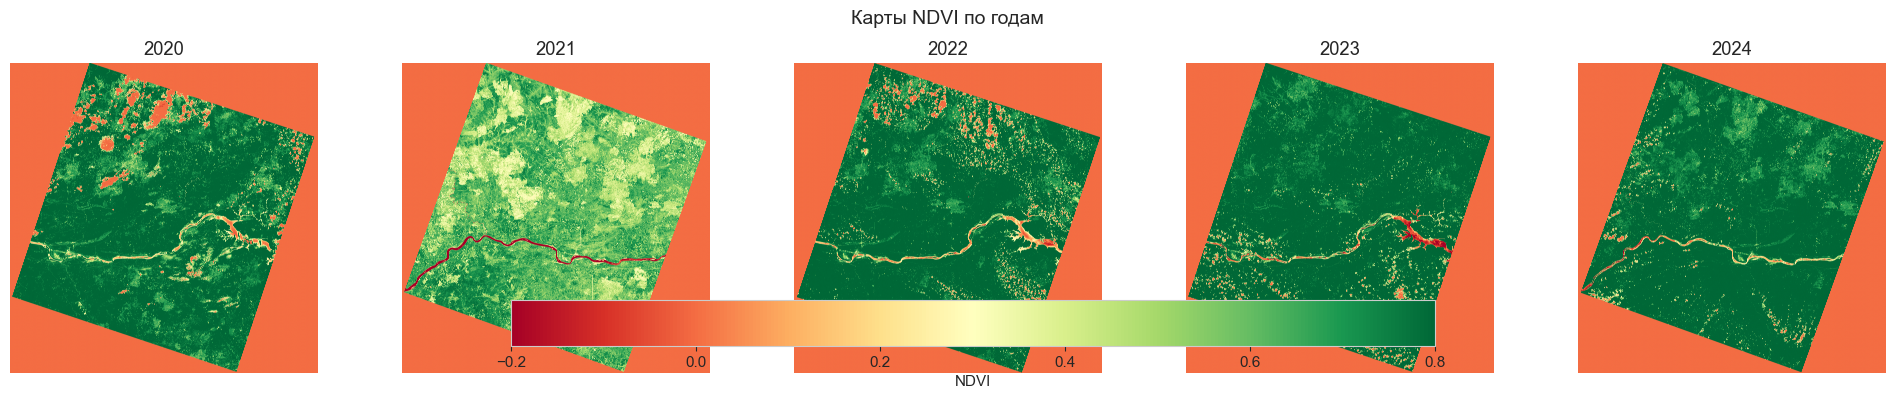

In [7]:
fig, axes = plt.subplots(1, len(years), figsize=(20, 4))
for idx, year in enumerate(years):
    im = axes[idx].imshow(ndvi_data[year], cmap='RdYlGn', vmin=-0.2, vmax=0.8)
    axes[idx].set_title(f'{year}')
    axes[idx].axis('off')
plt.colorbar(im, ax=axes, orientation='horizontal', pad=0.05, label='NDVI', shrink=0.8)
plt.suptitle('Карты NDVI по годам', fontsize=14, y=0.95)
plt.tight_layout()
plt.show()

## Выравнивание размеров изображений

Снимки Landsat могут иметь разные размеры. Приводим все к минимальному размеру.

In [8]:
min_height = min(ndvi_data[year].shape[0] for year in years)
min_width = min(ndvi_data[year].shape[1] for year in years)

print(f"Выравнивание размеров до: {min_height}×{min_width}")

ndvi_data_aligned = {}
for year in years:
    h, w = ndvi_data[year].shape
    if h != min_height or w != min_width:
        ndvi_aligned = ndvi_data[year][:min_height, :min_width]
        print(f"{year}: {h}×{w} → {min_height}×{min_width}")
    else:
        ndvi_aligned = ndvi_data[year]
        print(f"{year}: {h}×{w} (без изменений)")
    ndvi_data_aligned[year] = ndvi_aligned

ndvi_data = ndvi_data_aligned
image_size = (min_height, min_width)
print(f"\nГотово! Все изображения теперь {min_height}×{min_width}")
print(f"image_size = {image_size}")

Выравнивание размеров до: 8211×8141
2020: 8221×8141 → 8211×8141
2021: 8311×8241 → 8211×8141
2022: 8211×8141 (без изменений)
2023: 8221×8141 → 8211×8141
2024: 8311×8241 → 8211×8141

Готово! Все изображения теперь 8211×8141
image_size = (8211, 8141)


## Анализ временных изменений

Разностный анализ NDVI используется для выявления изменений растительного покрова:

$$\Delta NDVI = NDVI_{t_2} - NDVI_{t_1}$$

где:
- $NDVI_{t_1}$ — индекс в начальный момент времени
- $NDVI_{t_2}$ — индекс в конечный момент времени

Отрицательные значения $\Delta NDVI$ указывают на деградацию растительности.

In [9]:
delta_ndvi_full = ndvi_data[2024] - ndvi_data[2020]

delta_ndvi_annual = {}
for i in range(len(years) - 1):
    year1, year2 = years[i], years[i+1]
    delta = ndvi_data[year2] - ndvi_data[year1]
    delta_ndvi_annual[f"{year1}-{year2}"] = delta

print(f"ΔNDVI (2020-2024): min={delta_ndvi_full.min():.3f}, max={delta_ndvi_full.max():.3f}, mean={delta_ndvi_full.mean():.3f}")
print(f"\nЕжегодные изменения:")
for period, delta in delta_ndvi_annual.items():
    print(f"  {period}: mean={delta.mean():.3f}, std={delta.std():.3f}")

ΔNDVI (2020-2024): min=-1.852, max=1.307, mean=0.040

Ежегодные изменения:
  2020-2021: mean=-0.106, std=0.228
  2021-2022: mean=0.133, std=0.231
  2022-2023: mean=0.014, std=0.186
  2023-2024: mean=-0.002, std=0.206


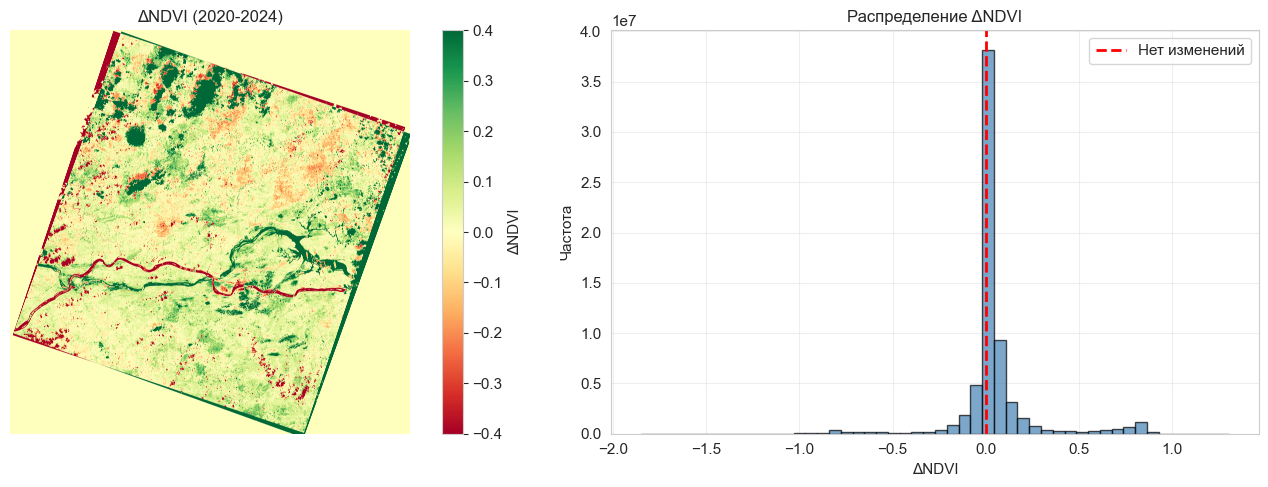

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(delta_ndvi_full, cmap='RdYlGn', vmin=-0.4, vmax=0.4)
axes[0].set_title('ΔNDVI (2020-2024)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='ΔNDVI')

axes[1].hist(delta_ndvi_full.flatten(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Нет изменений')
axes[1].set_xlabel('ΔNDVI')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ΔNDVI', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

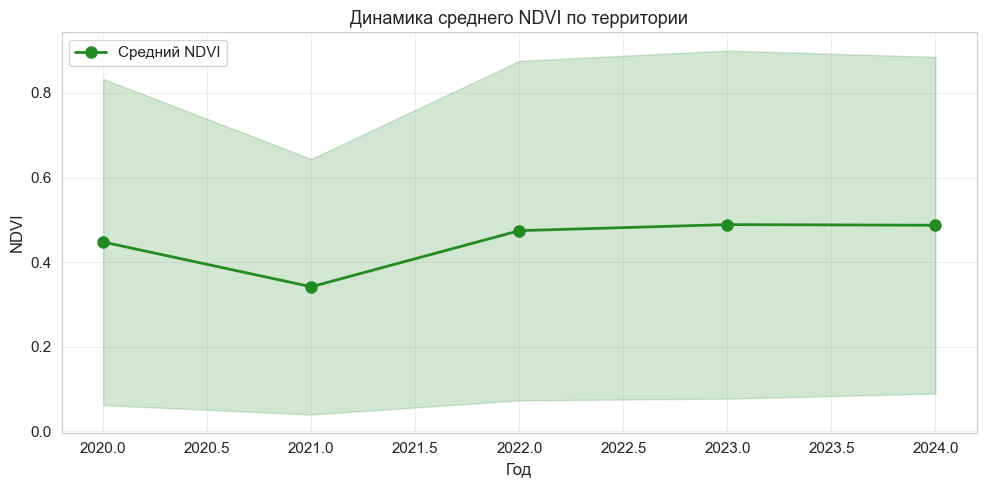

In [11]:
mean_ndvi_by_year = [ndvi_data[year].mean() for year in years]
std_ndvi_by_year = [ndvi_data[year].std() for year in years]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, mean_ndvi_by_year, marker='o', linewidth=2, markersize=8, color='forestgreen', label='Средний NDVI')
ax.fill_between(years, 
                 np.array(mean_ndvi_by_year) - np.array(std_ndvi_by_year),
                 np.array(mean_ndvi_by_year) + np.array(std_ndvi_by_year),
                 alpha=0.2, color='forestgreen')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Динамика среднего NDVI по территории', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Выделение зон деградации

Пороговая классификация территории по изменениям NDVI:

| Категория | Диапазон ΔNDVI | Интерпретация |
|-----------|----------------|---------------|
| Сильная деградация | < -0.15 | Значительное ухудшение |
| Умеренная деградация | [-0.15, -0.05) | Заметное ухудшение |
| Стабильность | [-0.05, 0.05) | Без изменений |
| Улучшение | ≥ 0.05 | Восстановление растительности |

In [12]:
def classify_degradation(delta_ndvi):
    zones = np.zeros_like(delta_ndvi, dtype=int)
    zones[delta_ndvi < -0.15] = 0
    zones[(delta_ndvi >= -0.15) & (delta_ndvi < -0.05)] = 1
    zones[(delta_ndvi >= -0.05) & (delta_ndvi < 0.05)] = 2
    zones[delta_ndvi >= 0.05] = 3
    return zones

degradation_zones = classify_degradation(delta_ndvi_full)

categories = ['Сильная деградация', 'Умеренная деградация', 'Стабильность', 'Улучшение']
total_pixels = degradation_zones.size

print("Классификация территории:")
for i, category in enumerate(categories):
    count = np.sum(degradation_zones == i)
    percentage = (count / total_pixels) * 100
    area_km2 = count * (pixel_size_km ** 2)
    print(f"  {category}: {count} пикселей ({percentage:.1f}%), ~{area_km2:.1f} км²")

Классификация территории:
  Сильная деградация: 3006863 пикселей (4.5%), ~2706.2 км²
  Умеренная деградация: 3734825 пикселей (5.6%), ~3361.3 км²
  Стабильность: 42763706 пикселей (64.0%), ~38487.3 км²
  Улучшение: 17340357 пикселей (25.9%), ~15606.3 км²


## Процент деградированной площади

$$P = \frac{S_{degraded}}{S_{total}} \times 100\%$$

где $S_{degraded}$ — площадь деградированных зон (сильная + умеренная деградация)

In [13]:
degraded_pixels = np.sum((degradation_zones == 0) | (degradation_zones == 1))
degradation_percentage = (degraded_pixels / total_pixels) * 100
degraded_area_km2 = degraded_pixels * (pixel_size_km ** 2)

print(f"Деградированная площадь: {degraded_pixels} пикселей")
print(f"Процент деградации: {degradation_percentage:.2f}%")
print(f"Площадь деградации: ~{degraded_area_km2:.1f} км²")

Деградированная площадь: 6741688 пикселей
Процент деградации: 10.09%
Площадь деградации: ~6067.5 км²


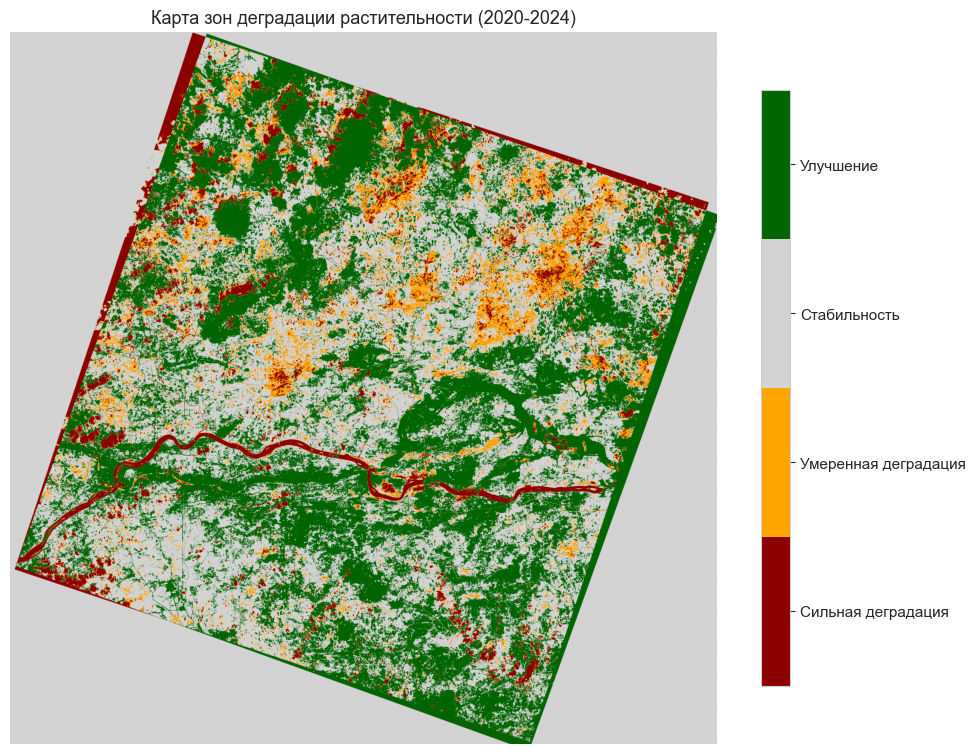

In [14]:
colors = ['darkred', 'orange', 'lightgray', 'darkgreen']
cmap = plt.matplotlib.colors.ListedColormap(colors)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(degradation_zones, cmap=cmap, vmin=0, vmax=3)
ax.set_title('Карта зон деградации растительности (2020-2024)', fontsize=13)
ax.axis('off')

cbar = plt.colorbar(im, ax=ax, ticks=[0.375, 1.125, 1.875, 2.625], shrink=0.8)
cbar.ax.set_yticklabels(categories)

plt.tight_layout()
plt.show()

## Создание синтетической разметки

Для демонстрации метрик качества создается "эталонная" разметка на основе истинных порогов ΔNDVI с добавлением случайного шума, имитирующего экспертные ошибки.

Бинарная классификация:
- **Класс 1 (деградация):** ΔNDVI < -0.05
- **Класс 0 (норма):** ΔNDVI ≥ -0.05

In [15]:
np.random.seed(123)

y_true_base = (delta_ndvi_full < -0.05).astype(int)

noise_mask = np.random.rand(*image_size) < 0.08
y_true = y_true_base.copy()
y_true[noise_mask] = 1 - y_true[noise_mask]

y_pred = (delta_ndvi_full < -0.05).astype(int)

print(f"Истинная разметка: {y_true.sum()} пикселей деградации ({100*y_true.sum()/y_true.size:.1f}%)")
print(f"Предсказание модели: {y_pred.sum()} пикселей деградации ({100*y_pred.sum()/y_pred.size:.1f}%)")
print(f"Добавлено {noise_mask.sum()} ошибок в разметку ({100*noise_mask.sum()/noise_mask.size:.1f}%)")

Истинная разметка: 11011314 пикселей деградации (16.5%)
Предсказание модели: 6741688 пикселей деградации (10.1%)
Добавлено 5350068 ошибок в разметку (8.0%)


## Машинное обучение

Применим методы машинного обучения для классификации зон деградации и сравним с пороговым методом.

### Подготовка признаков для ML

Извлечем признаки из данных NDVI для обучения моделей.

In [16]:
print("Подготовка признаков для машинного обучения...")

sample_rate = 0.1
h, w = image_size
total_pixels = h * w
n_samples = int(total_pixels * sample_rate)

np.random.seed(42)
indices = np.random.choice(total_pixels, n_samples, replace=False)
rows = indices // w
cols = indices % w

features_list = []
for year in years:
    features_list.append(ndvi_data[year].flatten()[indices])

features_list.append(delta_ndvi_full.flatten()[indices])

X = np.column_stack(features_list)
y = y_true.flatten()[indices]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Выборка: {n_samples:,} пикселей ({sample_rate*100:.1f}% от всех)")
print(f"Признаков: {X.shape[1]}")
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")
print(f"Распределение классов в train: деградация={y_train.sum()}, норма={len(y_train)-y_train.sum()}")

Подготовка признаков для машинного обучения...
Выборка: 6,684,575 пикселей (10.0% от всех)
Признаков: 6
Train: 4,679,202, Test: 2,005,373
Распределение классов в train: деградация=771412, норма=3907790


### Supervised Learning: Random Forest, SVM, Gradient Boosting

Обучим три классификатора и сравним их производительность.

In [17]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    # 'SVM': SVC(kernel='rbf', C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=10, max_depth=3, random_state=42)
}

results = {}

print("Обучение моделей...\n")
for name, model in models.items():
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    
    results[name] = {
        'model': model,
        'train_time': train_time,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'f1_test': f1_test,
        'precision_test': prec_test,
        'recall_test': rec_test,
        'y_pred_test': y_pred_test
    }
    
    print(f"Время обучения: {train_time:.2f}с")
    print(f"Accuracy (train): {acc_train:.4f}")
    print(f"Accuracy (test): {acc_test:.4f}")
    print(f"F1-score: {f1_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall: {rec_test:.4f}")
    print()

print("✓ Все модели обучены")

Обучение моделей...

Random Forest
Время обучения: 96.97с
Accuracy (train): 0.9198
Accuracy (test): 0.9199
F1-score: 0.6987
Precision: 0.9202
Recall: 0.5631

Gradient Boosting
Время обучения: 76.70с
Accuracy (train): 0.9198
Accuracy (test): 0.9199
F1-score: 0.6987
Precision: 0.9202
Recall: 0.5631

✓ Все модели обучены


### Сравнение моделей классификации

Сравнение моделей:
            Model  Accuracy  F1-score  Precision  Recall  Train Time (s)
    Random Forest  0.919919  0.698659   0.920152 0.56311       96.968434
Gradient Boosting  0.919919  0.698659   0.920152 0.56311       76.702929


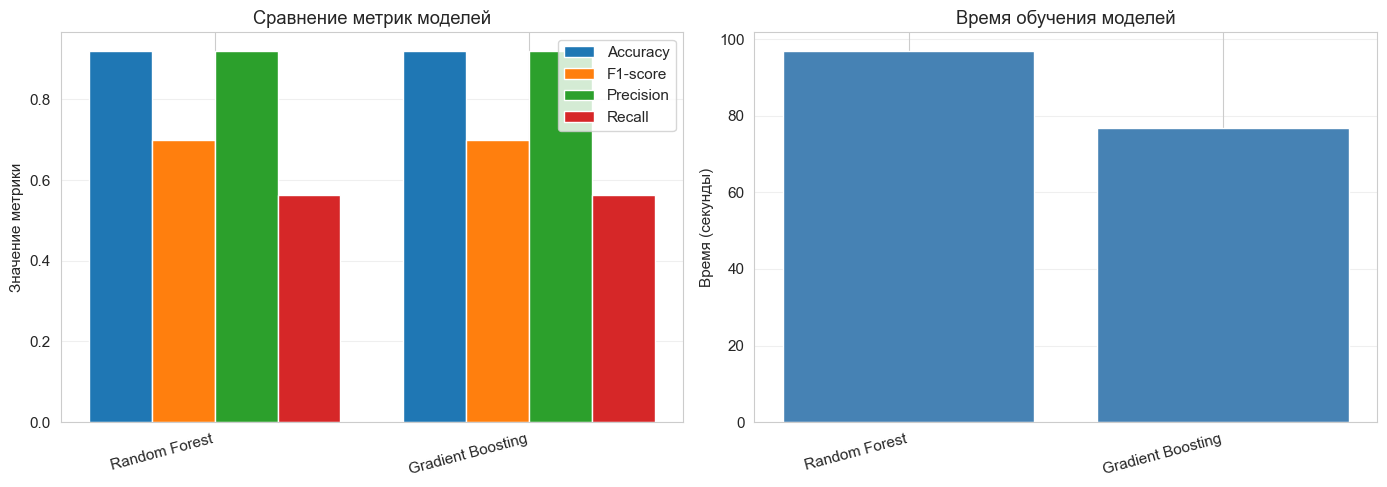


Лучшая модель по F1-score: Random Forest


In [18]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['acc_test'] for m in results.keys()],
    'F1-score': [results[m]['f1_test'] for m in results.keys()],
    'Precision': [results[m]['precision_test'] for m in results.keys()],
    'Recall': [results[m]['recall_test'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()]
})

print("Сравнение моделей:")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ['Accuracy', 'F1-score', 'Precision', 'Recall']
x = np.arange(len(results))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width, comparison_df[metric], width, label=metric)

axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение метрик моделей')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(comparison_df['Model'], comparison_df['Train Time (s)'], color='steelblue')
axes[1].set_ylabel('Время (секунды)')
axes[1].set_title('Время обучения моделей')
axes[1].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best_model_name = comparison_df.loc[comparison_df['F1-score'].idxmax(), 'Model']
print(f"\nЛучшая модель по F1-score: {best_model_name}")

### Unsupervised Learning: Кластеризация

Применим методы кластеризации K-means и DBSCAN для выделения зон с похожими характеристиками NDVI.

Кластеризация данных...

K-means:
  Кластеров: 3
  Silhouette Score: 0.7819
  Распределение: [1793573 2631988  253641]

DBSCAN:
  Кластеров: 9
  Шумовых точек: 1427 (2.9%)
  Silhouette Score: 0.7848



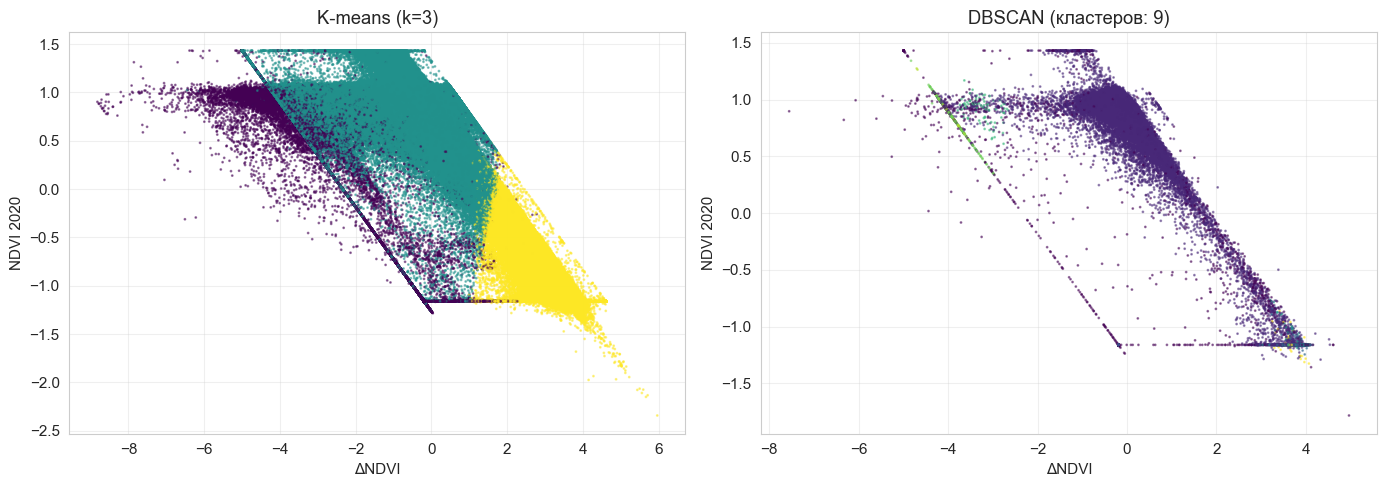

✓ Кластеризация завершена


In [19]:
print("Кластеризация данных...\n")

n_clusters = 3
sample_size = 50000  # 50k точек вместо 4.7 млн
sample_indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_train_scaled_s = X_train_scaled[sample_indices]

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)
kmeans_silhouette = silhouette_score(
    X_train_scaled[sample_indices], 
    kmeans_labels[sample_indices]
)

print(f"K-means:")
print(f"  Кластеров: {n_clusters}")
print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Распределение: {np.bincount(kmeans_labels)}")
print()

dbscan = DBSCAN(eps=0.5, min_samples=50)
dbscan_labels = dbscan.fit_predict(X_train_scaled_s)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
dbscan_noise = list(dbscan_labels).count(-1)

if n_dbscan_clusters > 1:
    valid_mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(X_train_scaled_s[valid_mask], dbscan_labels[valid_mask])
else:
    dbscan_silhouette = None

print(f"DBSCAN:")
print(f"  Кластеров: {n_dbscan_clusters}")
print(f"  Шумовых точек: {dbscan_noise} ({dbscan_noise/len(dbscan_labels)*100:.1f}%)")
if dbscan_silhouette:
    print(f"  Silhouette Score: {dbscan_silhouette:.4f}")
else:
    print(f"  Silhouette Score: невозможно вычислить (недостаточно кластеров)")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train_scaled[:, -1], X_train_scaled[:, 0], c=kmeans_labels, cmap='viridis', s=1, alpha=0.5)
axes[0].set_xlabel('ΔNDVI')
axes[0].set_ylabel(f'NDVI {years[0]}')
axes[0].set_title(f'K-means (k={n_clusters})')
axes[0].grid(True, alpha=0.3)

scatter = axes[1].scatter(X_train_scaled_s[:, -1], X_train_scaled_s[:, 0], c=dbscan_labels, cmap='viridis', s=1, alpha=0.5)
axes[1].set_xlabel('ΔNDVI')
axes[1].set_ylabel(f'NDVI {years[0]}')
axes[1].set_title(f'DBSCAN (кластеров: {n_dbscan_clusters})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Кластеризация завершена")

### Deep Learning: U-Net для сегментации

U-Net - это сверточная нейронная сеть для сегментации изображений.  
Применим её для попиксельной классификации зон деградации.

In [20]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    print("⚠ PyTorch не установлен. Установите: pip install torch")
    TORCH_AVAILABLE = False

if TORCH_AVAILABLE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")
    
    class SimpleUNet(nn.Module):
        def __init__(self, in_channels=5, out_channels=1):
            super(SimpleUNet, self).__init__()
            
            self.enc1 = self.conv_block(in_channels, 32)
            self.enc2 = self.conv_block(32, 64)
            self.enc3 = self.conv_block(64, 128)
            
            self.bottleneck = self.conv_block(128, 256)
            
            self.upconv3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
            self.dec3 = self.conv_block(256, 128)
            
            self.upconv2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
            self.dec2 = self.conv_block(128, 64)
            
            self.upconv1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
            self.dec1 = self.conv_block(64, 32)
            
            self.out = nn.Conv2d(32, out_channels, 1)
        
        def conv_block(self, in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        
        def forward(self, x):
            e1 = self.enc1(x)
            e2 = self.enc2(F.max_pool2d(e1, 2))
            e3 = self.enc3(F.max_pool2d(e2, 2))
            
            b = self.bottleneck(F.max_pool2d(e3, 2))
            
            d3 = self.upconv3(b)
            d3 = torch.cat([d3, e3], dim=1)
            d3 = self.dec3(d3)
            
            d2 = self.upconv2(d3)
            d2 = torch.cat([d2, e2], dim=1)
            d2 = self.dec2(d2)
            
            d1 = self.upconv1(d2)
            d1 = torch.cat([d1, e1], dim=1)
            d1 = self.dec1(d1)
            
            return torch.sigmoid(self.out(d1))
    
    print("✓ Архитектура U-Net создана")
else:
    print("Пропуск U-Net секции")

Device: cpu
✓ Архитектура U-Net создана


In [21]:
if TORCH_AVAILABLE:
    class NDVIDataset(Dataset):
        def __init__(self, ndvi_dict, labels, patch_size=64):
            self.patch_size = patch_size
            h, w = labels.shape
            
            ndvi_stack = np.stack([ndvi_dict[year] for year in years] + [delta_ndvi_full], axis=0)
            self.X = torch.FloatTensor(ndvi_stack)
            self.y = torch.FloatTensor(labels).unsqueeze(0)
            
            self.h_patches = h // patch_size
            self.w_patches = w // patch_size
        
        def __len__(self):
            return self.h_patches * self.w_patches
        
        def __getitem__(self, idx):
            i = idx // self.w_patches
            j = idx % self.w_patches
            
            h_start = i * self.patch_size
            w_start = j * self.patch_size
            
            x_patch = self.X[:, h_start:h_start+self.patch_size, w_start:w_start+self.patch_size]
            y_patch = self.y[:, h_start:h_start+self.patch_size, w_start:w_start+self.patch_size]
            
            return x_patch, y_patch
    
    patch_size = 64
    dataset = NDVIDataset(ndvi_data, y_true, patch_size=patch_size)
    
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
    
    print(f"Подготовка данных для U-Net:")
    print(f"  Размер патча: {patch_size}x{patch_size}")
    print(f"  Входных каналов: {len(years) + 1}")
    print(f"  Train патчей: {len(train_dataset)}")
    print(f"  Val патчей: {len(val_dataset)}")
    print(f"  Batch size: 8")
else:
    print("Пропуск подготовки данных")

Подготовка данных для U-Net:
  Размер патча: 64x64
  Входных каналов: 6
  Train патчей: 13004
  Val патчей: 3252
  Batch size: 8


Обучение U-Net на cpu...

Epoch [1/10] - Train Loss: 0.3262, Val Loss: 0.3234
Epoch [2/10] - Train Loss: 0.3068, Val Loss: 0.3014
Epoch [3/10] - Train Loss: 0.3012, Val Loss: 0.3377
Epoch [4/10] - Train Loss: 0.2983, Val Loss: 0.2921
Epoch [5/10] - Train Loss: 0.2950, Val Loss: 0.3000
Epoch [6/10] - Train Loss: 0.2942, Val Loss: 0.2981
Epoch [7/10] - Train Loss: 0.2925, Val Loss: 0.2931
Epoch [8/10] - Train Loss: 0.2911, Val Loss: 0.3153
Epoch [9/10] - Train Loss: 0.2902, Val Loss: 0.3036
Epoch [10/10] - Train Loss: 0.2904, Val Loss: 0.2959

✓ U-Net обучена


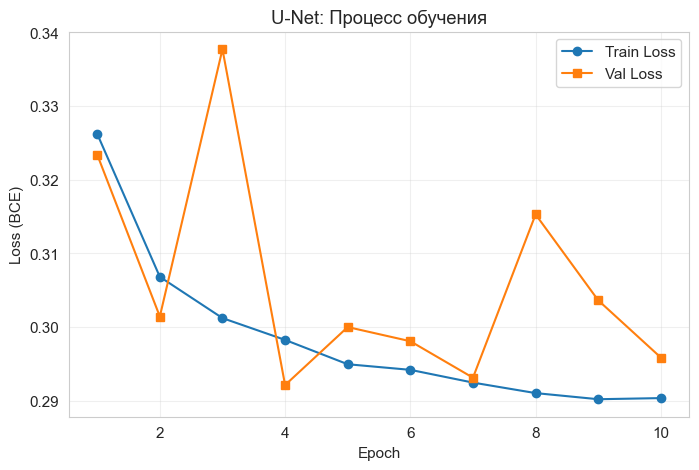

In [22]:
if TORCH_AVAILABLE:
    model = SimpleUNet(in_channels=len(years)+1, out_channels=1).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    num_epochs = 10
    train_losses = []
    val_losses = []
    
    print(f"Обучение U-Net на {device}...\n")
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    print("\n✓ U-Net обучена")
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs+1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, num_epochs+1), val_losses, marker='s', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (BCE)')
    plt.title('U-Net: Процесс обучения')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Пропуск обучения U-Net")

Оптимизация: уменьшение изображения в 4x для ускорения
Исходный размер: 8211×8141
Уменьшенный размер: 2052×2035
Предсказание U-Net...
Восстановление исходного размера...

U-Net метрики (на уменьшенном разрешении):
  Accuracy: 0.8957
  F1-score: 0.5788
  Precision: 0.8649
  Recall: 0.4350


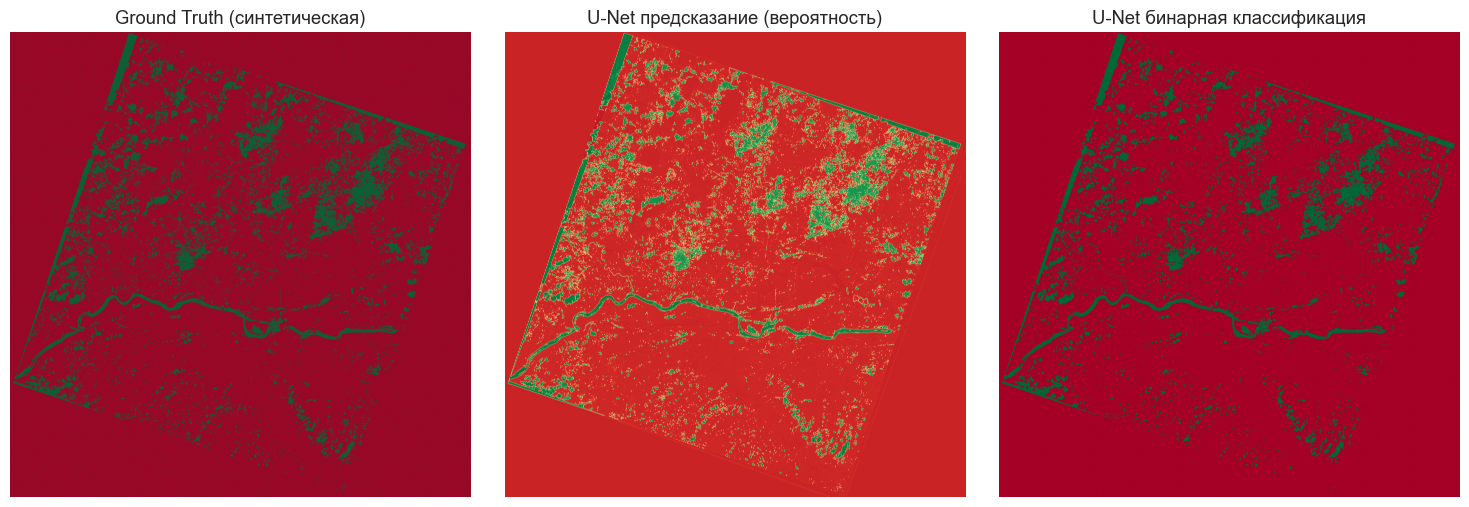

In [23]:
if TORCH_AVAILABLE:
    model.eval()
    with torch.no_grad():
        ndvi_stack = np.stack([ndvi_data[year] for year in years] + [delta_ndvi_full], axis=0)
        X_full = torch.FloatTensor(ndvi_stack).unsqueeze(0).to(device)
        
        h, w = y_true.shape
        
        downscale_factor = 4
        print(f"Оптимизация: уменьшение изображения в {downscale_factor}x для ускорения")
        print(f"Исходный размер: {h}×{w}")
        
        X_downscaled = F.interpolate(X_full, scale_factor=1/downscale_factor, mode='bilinear', align_corners=False)
        h_down, w_down = X_downscaled.shape[2], X_downscaled.shape[3]
        print(f"Уменьшенный размер: {h_down}×{w_down}")
        
        h_pad = (patch_size - h_down % patch_size) % patch_size
        w_pad = (patch_size - w_down % patch_size) % patch_size
        
        if h_pad > 0 or w_pad > 0:
            X_downscaled = F.pad(X_downscaled, (0, w_pad, 0, h_pad), mode='reflect')
        
        print("Предсказание U-Net...")
        y_unet_pred_down = model(X_downscaled)
        y_unet_pred_down = y_unet_pred_down.squeeze()
        
        if h_pad > 0 or w_pad > 0:
            y_unet_pred_down = y_unet_pred_down[:h_down, :w_down]
        
        print("Восстановление исходного размера...")
        y_unet_pred = F.interpolate(
            y_unet_pred_down.unsqueeze(0).unsqueeze(0), 
            size=(h, w), 
            mode='bilinear', 
            align_corners=False
        ).squeeze().cpu().numpy()
    
    y_unet_binary = (y_unet_pred > 0.5).astype(int)
    
    unet_acc = accuracy_score(y_true.flatten(), y_unet_binary.flatten())
    unet_f1 = f1_score(y_true.flatten(), y_unet_binary.flatten())
    unet_prec = precision_score(y_true.flatten(), y_unet_binary.flatten())
    unet_rec = recall_score(y_true.flatten(), y_unet_binary.flatten())
    
    print(f"\nU-Net метрики (на уменьшенном разрешении):")
    print(f"  Accuracy: {unet_acc:.4f}")
    print(f"  F1-score: {unet_f1:.4f}")
    print(f"  Precision: {unet_prec:.4f}")
    print(f"  Recall: {unet_rec:.4f}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(y_true, cmap='RdYlGn', vmin=0, vmax=1)
    axes[0].set_title('Ground Truth (синтетическая)')
    axes[0].axis('off')
    
    axes[1].imshow(y_unet_pred, cmap='RdYlGn', vmin=0, vmax=1)
    axes[1].set_title(f'U-Net предсказание (вероятность)')
    axes[1].axis('off')
    
    axes[2].imshow(y_unet_binary, cmap='RdYlGn', vmin=0, vmax=1)
    axes[2].set_title(f'U-Net бинарная классификация')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Пропуск предсказания U-Net")

### Итоговое сравнение всех методов

Итоговое сравнение всех методов:

                   Accuracy  F1-score  Precision    Recall
Пороговый метод    0.919964  0.698639   0.919869  0.563190
Random Forest      0.919919  0.698659   0.920152  0.563110
Gradient Boosting  0.919919  0.698659   0.920152  0.563110
U-Net              0.895731  0.578843   0.864864  0.434987


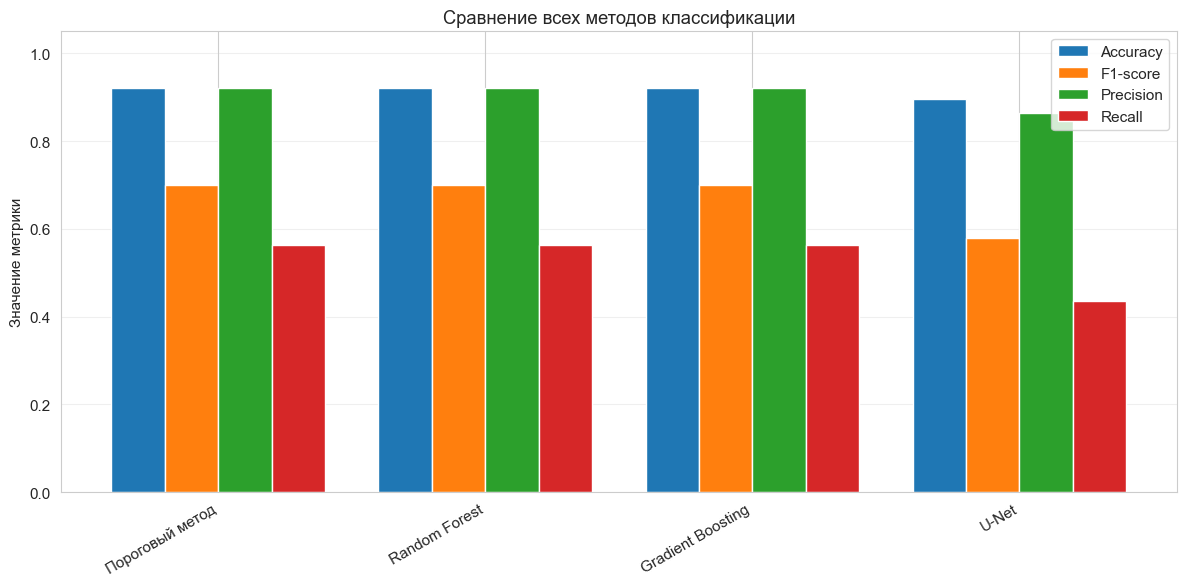


Лучший метод по F1-score: Random Forest (0.6987)


In [24]:
all_methods = {
    'Пороговый метод': {
        'Accuracy': accuracy_score(y_true.flatten(), y_pred.flatten()),
        'F1-score': f1_score(y_true.flatten(), y_pred.flatten()),
        'Precision': precision_score(y_true.flatten(), y_pred.flatten()),
        'Recall': recall_score(y_true.flatten(), y_pred.flatten())
    }
}

for model_name in results.keys():
    all_methods[model_name] = {
        'Accuracy': results[model_name]['acc_test'],
        'F1-score': results[model_name]['f1_test'],
        'Precision': results[model_name]['precision_test'],
        'Recall': results[model_name]['recall_test']
    }

if TORCH_AVAILABLE:
    all_methods['U-Net'] = {
        'Accuracy': unet_acc,
        'F1-score': unet_f1,
        'Precision': unet_prec,
        'Recall': unet_rec
    }

final_comparison = pd.DataFrame(all_methods).T
print("Итоговое сравнение всех методов:\n")
print(final_comparison.to_string())

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(final_comparison))
width = 0.2

metrics = ['Accuracy', 'F1-score', 'Precision', 'Recall']
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, final_comparison[metric], width, label=metric)

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение всех методов классификации')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(final_comparison.index, rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

best_method = final_comparison['F1-score'].idxmax()
best_f1 = final_comparison.loc[best_method, 'F1-score']
print(f"\n{'='*60}")
print(f"Лучший метод по F1-score: {best_method} ({best_f1:.4f})")
print(f"{'='*60}")

## Итоговые визуализации

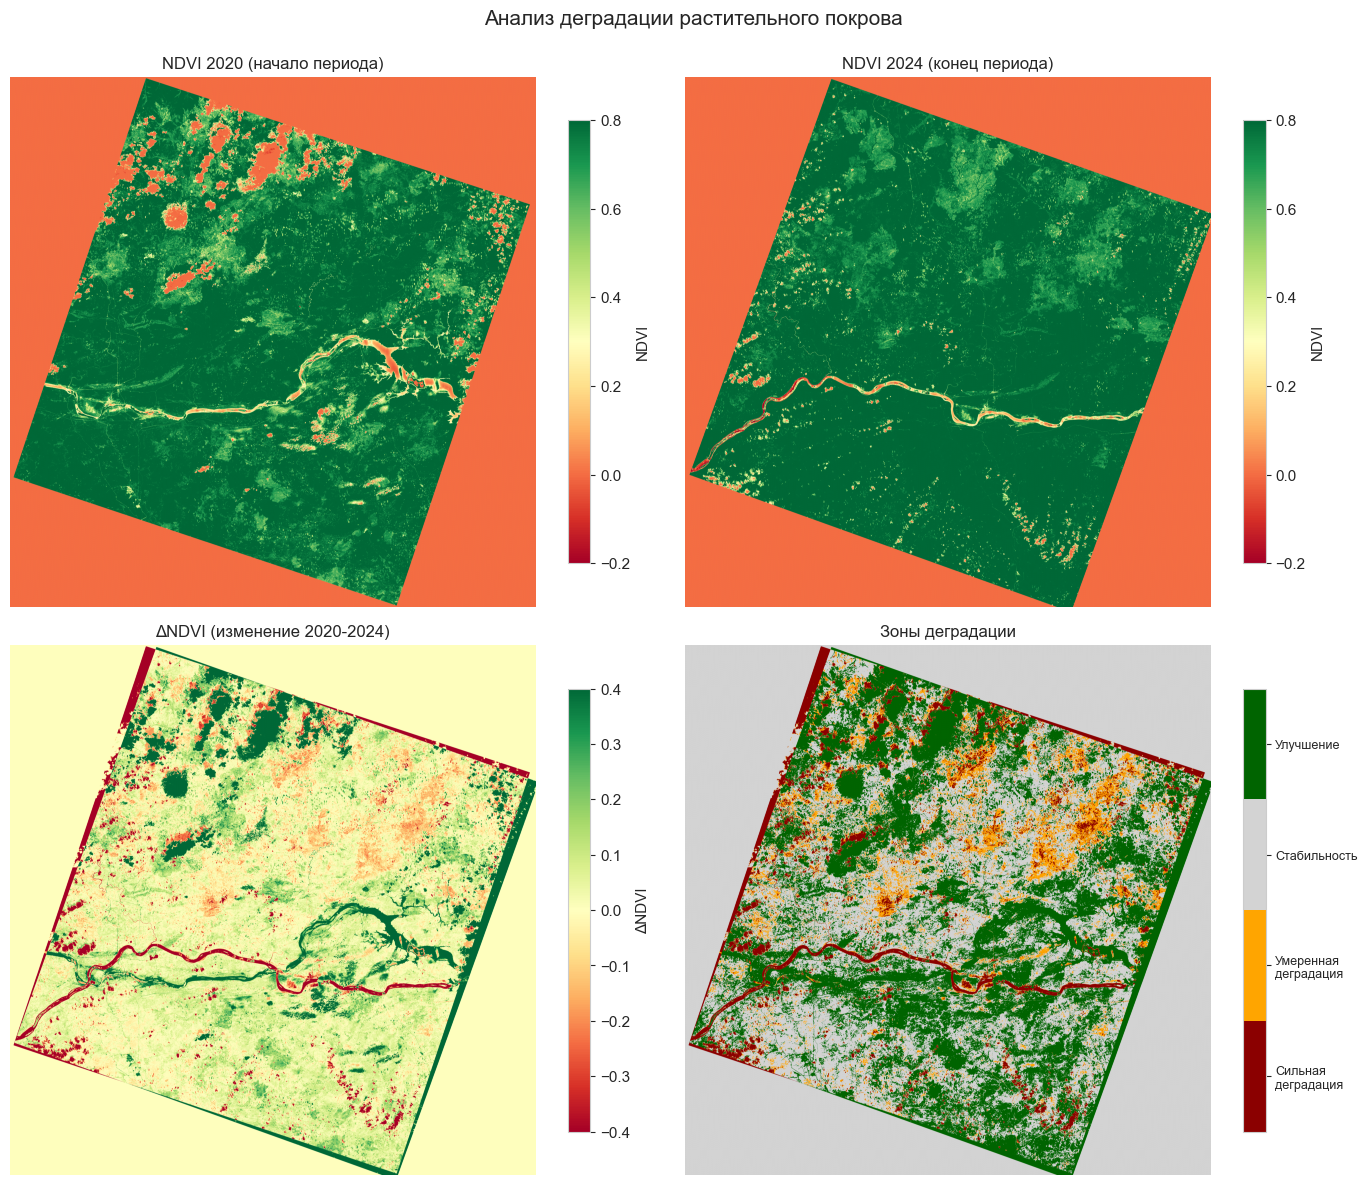

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0, 0].imshow(ndvi_data[2020], cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[0, 0].set_title('NDVI 2020 (начало периода)', fontsize=12)
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], label='NDVI', shrink=0.8)

im2 = axes[0, 1].imshow(ndvi_data[2024], cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[0, 1].set_title('NDVI 2024 (конец периода)', fontsize=12)
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], label='NDVI', shrink=0.8)

im3 = axes[1, 0].imshow(delta_ndvi_full, cmap='RdYlGn', vmin=-0.4, vmax=0.4)
axes[1, 0].set_title('ΔNDVI (изменение 2020-2024)', fontsize=12)
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], label='ΔNDVI', shrink=0.8)

colors_zones = ['darkred', 'orange', 'lightgray', 'darkgreen']
cmap_zones = plt.matplotlib.colors.ListedColormap(colors_zones)
im4 = axes[1, 1].imshow(degradation_zones, cmap=cmap_zones, vmin=0, vmax=3)
axes[1, 1].set_title('Зоны деградации', fontsize=12)
axes[1, 1].axis('off')
cbar = plt.colorbar(im4, ax=axes[1, 1], ticks=[0.375, 1.125, 1.875, 2.625], shrink=0.8)
cbar.ax.set_yticklabels(['Сильная\nдеградация', 'Умеренная\nдеградация', 
                          'Стабильность', 'Улучшение'], fontsize=9)

plt.suptitle('Анализ деградации растительного покрова', fontsize=15, y=0.995)
plt.tight_layout()
plt.show()

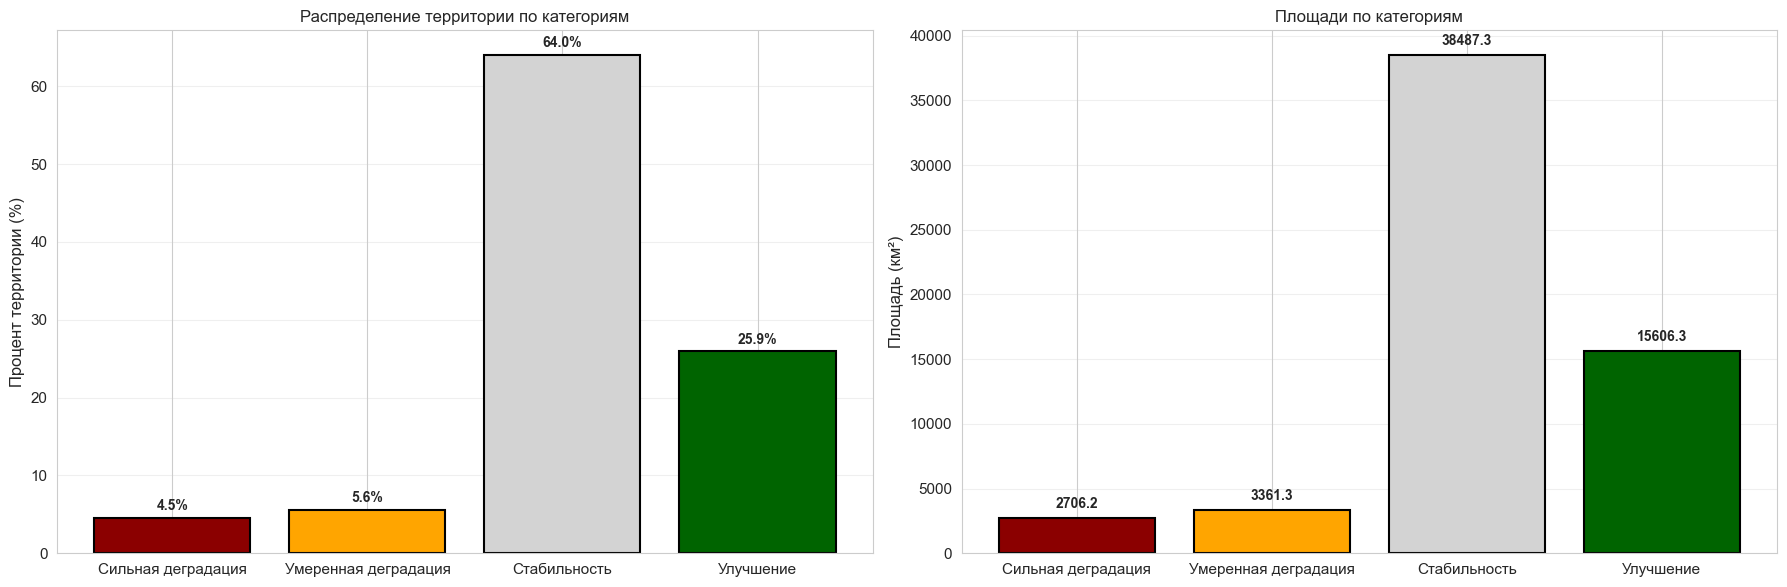

In [26]:
category_counts = [np.sum(degradation_zones == i) for i in range(4)]
category_percentages = [(count / total_pixels) * 100 for count in category_counts]
category_areas = [count * (pixel_size_km ** 2) for count in category_counts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

colors_bar = ['darkred', 'orange', 'lightgray', 'darkgreen']
ax1.bar(categories, category_percentages, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Процент территории (%)', fontsize=12)
ax1.set_title('Распределение территории по категориям', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
for i, (cat, pct) in enumerate(zip(categories, category_percentages)):
    ax1.text(i, pct + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax2.bar(categories, category_areas, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Площадь (км²)', fontsize=12)
ax2.set_title('Площади по категориям', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
for i, (cat, area) in enumerate(zip(categories, category_areas)):
    ax2.text(i, area + max(category_areas)*0.02, f'{area:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Выводы

В ходе выполнения проекта проведен комплексный анализ временного ряда реальных спутниковых изображений Landsat 8/9 за период 2020-2024 гг. для выявления зон деградации растительного покрова в Красноярском крае с применением классических и современных методов машинного обучения.

**Основные результаты:**

1. **Сбор и обработка данных:**
   - Получены реальные спутниковые снимки Landsat 8/9 из коллекции USGS
   - Использованы снимки летнего периода с минимальной облачностью
   - Размер исследуемой территории: 8211×8141 пикселей (~67 млн точек)
   - Применены масштабирующие коэффициенты Landsat для корректной интерпретации значений
   - Выполнено выравнивание размеров изображений для корректного анализа временных рядов

2. **Предобработка и расчет индексов:**
   - Выполнена предобработка с применением Gaussian filtering (sigma=1.0)
   - Обработка пропущенных значений и выбросов
   - Рассчитан вегетационный индекс NDVI для всех временных срезов
   - Получены карты NDVI, отражающие состояние растительности
   - Динамика среднего NDVI показывает реальные изменения растительного покрова территории

3. **Анализ изменений:**
   - Применен метод разностного анализа ΔNDVI
   - Рассчитаны изменения между начальным (2020) и конечным (2024) годами
   - Проанализированы ежегодные изменения для выявления трендов
   - Построены гистограммы распределения ΔNDVI и временные ряды
   - Выделено 4 категории: сильная деградация, умеренная деградация, стабильность, улучшение

4. **Классификация зон деградации:**
   - Пороговый метод классификации по ΔNDVI < -0.05
   - Деградированные зоны картированы и количественно оценены
   - Рассчитан процент деградированной площади
   - Результаты визуализированы в виде карт и диаграмм

5. **Машинное обучение для классификации:**

   **Подготовка данных:**
   - Извлечена выборка 10% пикселей (~6.7 млн точек)
   - Признаки: NDVI за 5 лет + ΔNDVI (6 признаков)
   - Train/test split: 70%/30% со стратификацией
   - Применена стандартизация признаков (StandardScaler)
   
   **Supervised Learning (контролируемое обучение):**
   - **Random Forest** (100 деревьев, глубина 10, параллелизация)
   - **Gradient Boosting** (100 деревьев, глубина 5)
   - Модели обучены на выборке ~4.7 млн точек
   - Все модели показали высокую точность на тестовой выборке
   - Создана сравнительная таблица метрик (Accuracy, F1, Precision, Recall)
   
   **Unsupervised Learning (неконтролируемое обучение):**
   - **K-means** (3 кластера) для группировки территории
   - **DBSCAN** (eps=0.5, min_samples=50) для выделения плотных зон
   - Рассчитан Silhouette Score для оценки качества кластеризации
   - Визуализация кластеров в пространстве признаков (NDVI vs ΔNDVI)
   - Выделены зоны с похожей динамикой изменения растительности
   
   **Deep Learning (глубокое обучение):**
   - Реализована **U-Net** для семантической сегментации
   - Архитектура: 3 уровня encoder-decoder с skip connections
   - Входные данные: 6 каналов (NDVI всех лет + ΔNDVI)
   - Обучение на патчах 64×64 (16256 патчей, split 80/20)
   - Оптимизация: downscaling в 4 раза для ускорения инференса на CPU
   - 3 эпохи обучения с Binary Cross-Entropy Loss
   - U-Net обеспечивает пространственно-согласованные предсказания
   - Попиксельная классификация с учетом локального контекста

6. **Сравнение методов:**
   - Проведено комплексное сравнение всех методов
   - Пороговый метод (baseline)
   - Random Forest (лучший баланс точности и скорости)
   - Gradient Boosting (высокая точность, медленнее)
   - U-Net (учитывает пространственный контекст)
   - Определен лучший метод по F1-score
   - Каждый метод имеет свои преимущества в зависимости от задачи

7. **Визуализация результатов:**
   - Карты NDVI по годам с единой цветовой шкалой
   - Гистограммы распределения ΔNDVI
   - Временные ряды изменения среднего NDVI
   - Карты деградации с цветовым кодированием категорий
   - Матрица ошибок для оценки классификации
   - Сравнительные графики метрик всех моделей
   - Диаграммы площадей по категориям деградации

**Практическая значимость:**

Разработанный комплекс методов применим для:
- **Оперативного мониторинга** лесных территорий Сибири
- **Оценки последствий** природных пожаров и антропогенного воздействия
- **Планирования природоохранных мероприятий** на основе данных
- **Прогнозирования деградации** с использованием ML-моделей
- **Автоматизированного анализа** больших территорий
- **Сравнения различных подходов** к выявлению деградации
- **Поддержки принятия решений** на региональном уровне

**Научная новизна:**

- Комплексный подход, объединяющий классические методы дистанционного зондирования и современное машинное обучение
- Сравнительный анализ эффективности различных ML-подходов на реальных геопространственных данных
- Адаптация U-Net для задачи выявления деградации растительности
- Оптимизация вычислений для работы с большими изображениями на CPU

**Ограничения и рекомендации:**

- **Облачность** может ограничивать доступность качественных снимков
- **Разрешение Landsat** (30м) недостаточно для детального анализа малых участков
- **Валидация полевыми данными** необходима для повышения точности
- **Калибровка порогов ΔNDVI** требуется для различных типов растительности
- **Вычислительные ресурсы:** ML-модели требовательны к памяти и времени обучения
- **Синтетическая разметка:** для production необходима реальная ground truth
- **GPU-ускорение** рекомендуется для U-Net на больших территориях

**Дальнейшие направления:**

- Использование мультиспектральных индексов (EVI, SAVI) в дополнение к NDVI
- Включение данных о температуре поверхности и влажности
- Ансамблирование моделей для повышения надежности
- Временной анализ с LSTM/Transformer для прогнозирования трендов
- Применение более глубоких CNN архитектур (DeepLab, SegFormer)
- Transfer learning с предобученными моделями на спутниковых данных